In [9]:
from os.path import join, dirname, abspath
import cv2
import matplotlib.pyplot as plt

In [3]:
def show_img(img, title=None):
    plt.imshow(img, vmin=0, vmax=1)
    if title:
        plt.title(title)
    # plt.axis('off')
    plt.show()

In [39]:
img_fp = r"C:\Users\gja\OneDrive - IDS Imaging\Bilder\peak\4108568781\image_8.png"
raw = cv2.imread(img_fp)
show_img(img, title="full")

In [44]:
img_crop = img[-1100:-400, 2000:2500]
img_top = img_crop[:400, :]
img_btm = img_crop[400:, :]
show_img(img_crop, title="crop")

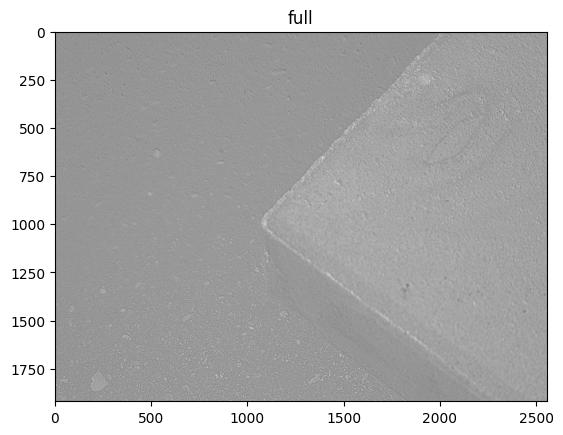

In [58]:
img_fp = r"C:\Users\gja\OneDrive - IDS Imaging\Bilder\peak\4108568781\image_4.png"
img = cv2.imread(img_fp)

nir_raw = img[1::2, 0::2].astype(np.float32)
red_raw = img[0::2, 1::2].astype(np.float32)
green_raw = img[0::2, 0::2].astype(np.float32)

import numpy as np
img_d = np.divide(nir_raw, red_raw)




show_img(img_d, title="full")


In [62]:
print(np.percentile(img_d, 99), np.percentile(img_d, 1), np.percentile(img_d, 50))

0.7368421 0.5140845 0.60465115


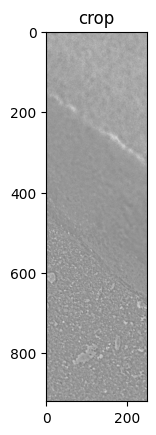

In [57]:
img_crop = img_d[1000:, 1250:1500]
show_img(img_crop, title="crop")

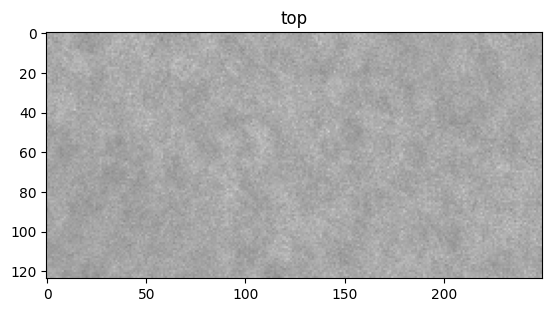

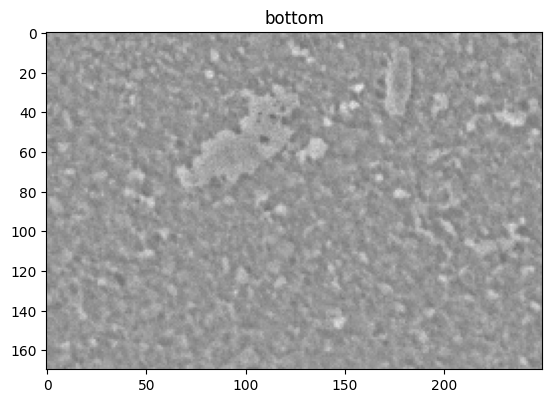

In [66]:

img_top = img_crop[:124, :]
img_btm = img_crop[750:, :]
show_img(img_top, title="top")
show_img(img_btm, title="bottom")

In [1]:
fp = r"C:\Users\gja\OneDrive - IDS Imaging\Bilder\peak\4110102903\image_0.png"
raw = cv2.imread(fp)
nir = raw[1::2, 0::2].astype(np.float32)
red = raw[0::2, 1::2].astype(np.float32)
green = raw[0::2, 0::2].astype(np.float32)
ndvi_raw=(nir-red)/(nir+red+np.float32(0.01)); cvi_raw=(nir*red)/(green*green+np.float32(0.01))

In [5]:
def normalize_with_bounds(image, lo, hi):
    if hi <= lo:return np.zeros_like(image,dtype=np.float32)
    return np.nan_to_num(np.clip((image-np.float32(lo))/np.float32(hi-lo),0,1),nan=0,posinf=1,neginf=0).astype(np.float32)

In [ ]:
ndvi=heatmap(normalize_with_bounds(ndvi_raw,*self._ndvi_bounds))
cvi=heatmap(normalize_with_bounds(cvi_raw,*self._cvi_bounds))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.29403117..0.33296338].


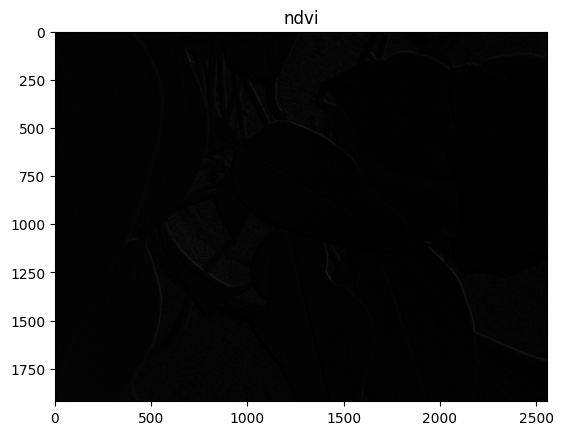

In [4]:
show_img(ndvi_raw, title="ndvi")

In [ ]:
_cmap = matplotlib.colormaps.get_cmap("RdYlGn").resampled(256)
plt.